文件元数据： {'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 126, 'height': 154, 'count': 12, 'crs': CRS.from_wkt('PROJCS["Krasovsky_1940_Albers",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",0],PARAMETER["longitude_of_center",105],PARAMETER["standard_parallel_1",25],PARAMETER["standard_parallel_2",47],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(1000.0, 0.0, 823414.1677141753,
       0.0, -1000.0, 3366046.3452970944), 'blockxsize': 126, 'blockysize': 1, 'tiled': False, 'interleave': 'pixel'}


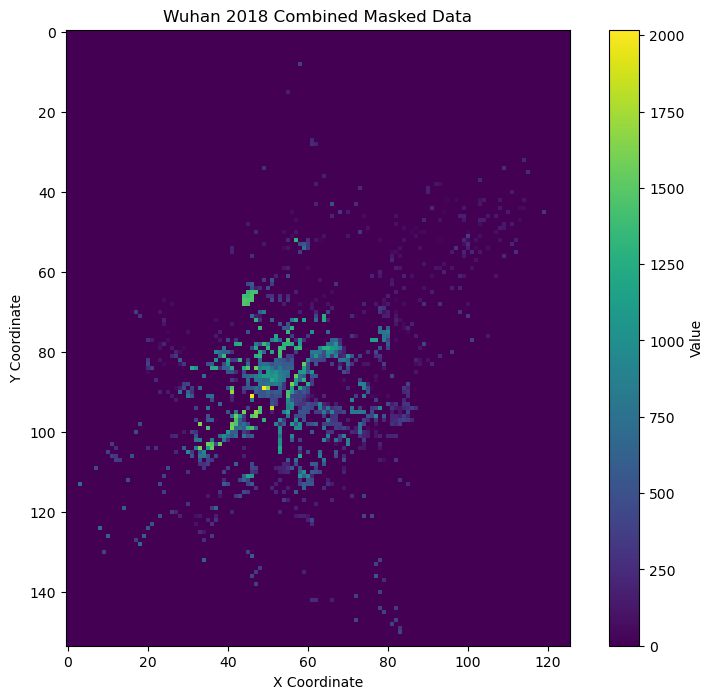

In [1]:
import rasterio
import matplotlib.pyplot as plt

# 文件路径
file_path = r'F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\wuhan_clipped\wuhan_2018_combined_masked.tif'

# 读取 GeoTIFF 文件
with rasterio.open(file_path) as src:
    data = src.read(1)  # 读取第一波段数据
    profile = src.profile  # 获取文件元数据

# 打印文件元数据
print("文件元数据：", profile)

# 可视化数据
plt.figure(figsize=(10, 8))
plt.imshow(data, cmap='viridis')  # 使用 Viridis 配色
plt.colorbar(label='Value')
plt.title('Wuhan 2018 Combined Masked Data')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

In [3]:
# 打印文件元数据
print("文件元数据：", profile)

# 获取数据的最小值和最大值
print("数据范围：", data.min(), data.max())

# 获取坐标范围
bounds = src.bounds
print("坐标范围：", bounds)

文件元数据： {'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 126, 'height': 154, 'count': 12, 'crs': CRS.from_wkt('PROJCS["Krasovsky_1940_Albers",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",0],PARAMETER["longitude_of_center",105],PARAMETER["standard_parallel_1",25],PARAMETER["standard_parallel_2",47],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(1000.0, 0.0, 823414.1677141753,
       0.0, -1000.0, 3366046.3452970944), 'blockxsize': 126, 'blockysize': 1, 'tiled': False, 'interleave': 'pixel'}
数据范围： 0.0 2018.0480241438995
坐标范围： BoundingBox(left=823414.1677141753, bottom=3212046.3452970944, right=949414.1677141753, top=3366046.3452970944)


正在进行坐标系转换...
裁剪后的建筑物数量: 34023


C:\Users\asus\AppData\Local\Temp\ipykernel_43392\3396898677.py:30: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\asus\AppData\Local\Temp\ipykernel_43392\3396898677.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\asus\AppData\Local\Temp\ipykernel_43392\3396898677.py:33: UserWarning: Glyph 27743 (\N{CJK UNIFIED IDEOGRAPH-6C5F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_43392\3396898677.py:33: UserWarning: Glyph 23736 (\N{CJK UNIFIED IDEOGRAPH-5CB8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_43392\3396898677.py:33: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH

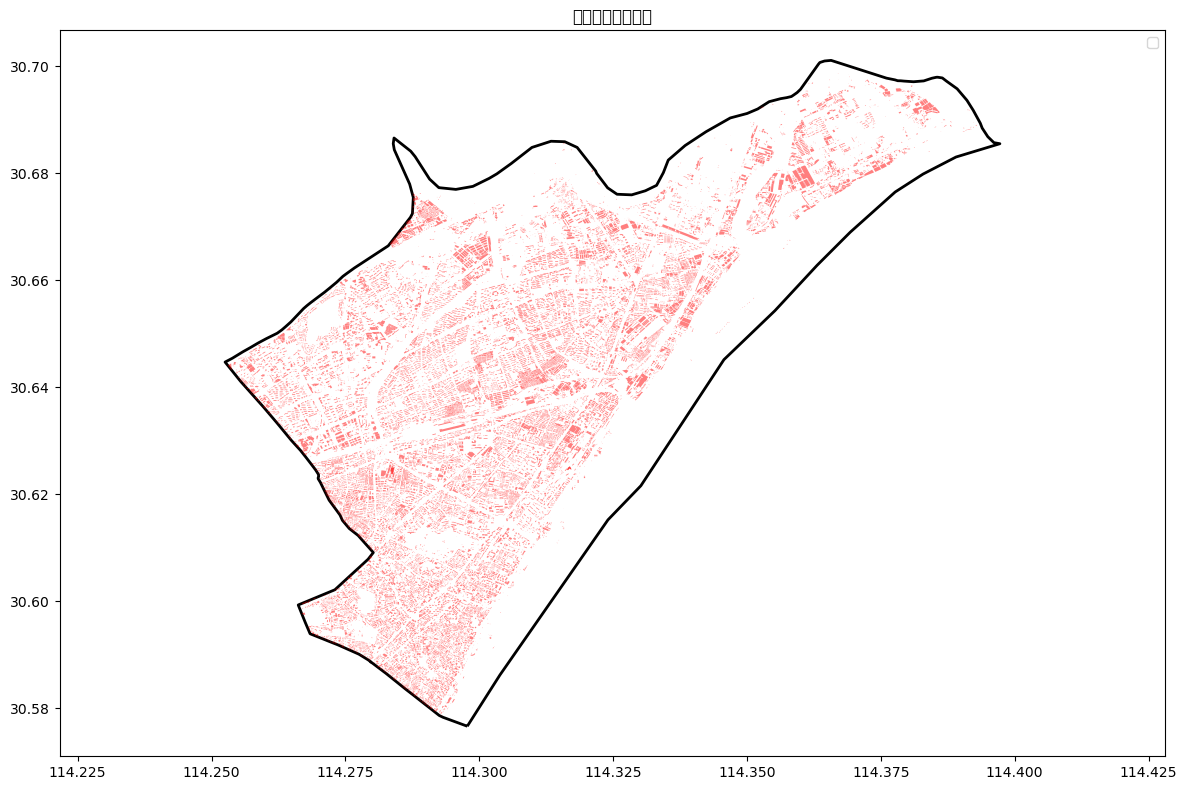

裁剪结果已保存到: F:\ScientificDatabase\paper03\wuhan_district\jiangan_buildings.shp


In [4]:
# 数据裁剪分析（江岸区）

import geopandas as gpd

# 读取江岸区边界数据
boundary_path = r"F:\ScientificDatabase\paper03\wuhan_district\jiang_an_district.shp"
boundary_gdf = gpd.read_file(boundary_path)

# 读取建筑物数据
building_path = r"F:\ScientificDatabase\paper03\wuhan_district\Wuhan_Building_GloBFP_with_area.shp"
buildings_gdf = gpd.read_file(building_path)

# 确保两个数据集的坐标参考系统一致
if boundary_gdf.crs != buildings_gdf.crs:
    print("正在进行坐标系转换...")
    buildings_gdf = buildings_gdf.to_crs(boundary_gdf.crs)

# 使用江岸区边界裁剪建筑物数据
jiangan_buildings = gpd.clip(buildings_gdf, boundary_gdf)

# 输出裁剪结果
print(f"裁剪后的建筑物数量: {len(jiangan_buildings)}")

# 可视化裁剪结果
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2, label='江岸区边界')
jiangan_buildings.plot(ax=ax, color='red', alpha=0.5, label='建筑物')
plt.legend()
plt.title("江岸区建筑物分布")
plt.axis('equal')
plt.tight_layout()
plt.show()

# 保存裁剪结果到新的 Shapefile 文件（可选）
output_path = r"F:\ScientificDatabase\paper03\wuhan_district\jiangan_buildings.shp"
jiangan_buildings.to_file(output_path)
print(f"裁剪结果已保存到: {output_path}")

正在进行坐标系转换...
数据表格已保存到: F:\ScientificDatabase\paper03\wuhan_district\building_energy_data.csv


C:\Users\asus\AppData\Local\Temp\ipykernel_43392\1794904263.py:49: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_43392\1794904263.py:49: UserWarning: Glyph 31569 (\N{CJK UNIFIED IDEOGRAPH-7B51}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_43392\1794904263.py:49: UserWarning: Glyph 29289 (\N{CJK UNIFIED IDEOGRAPH-7269}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_43392\1794904263.py:49: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_43392\1794904263.py:49: UserWarning: Glyph 28304 (\N{CJK UNIFIED IDEOGRAPH-6E90}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_43392\1794904263.py:49: UserWarning: Glyph 28040 (\N{CJK 

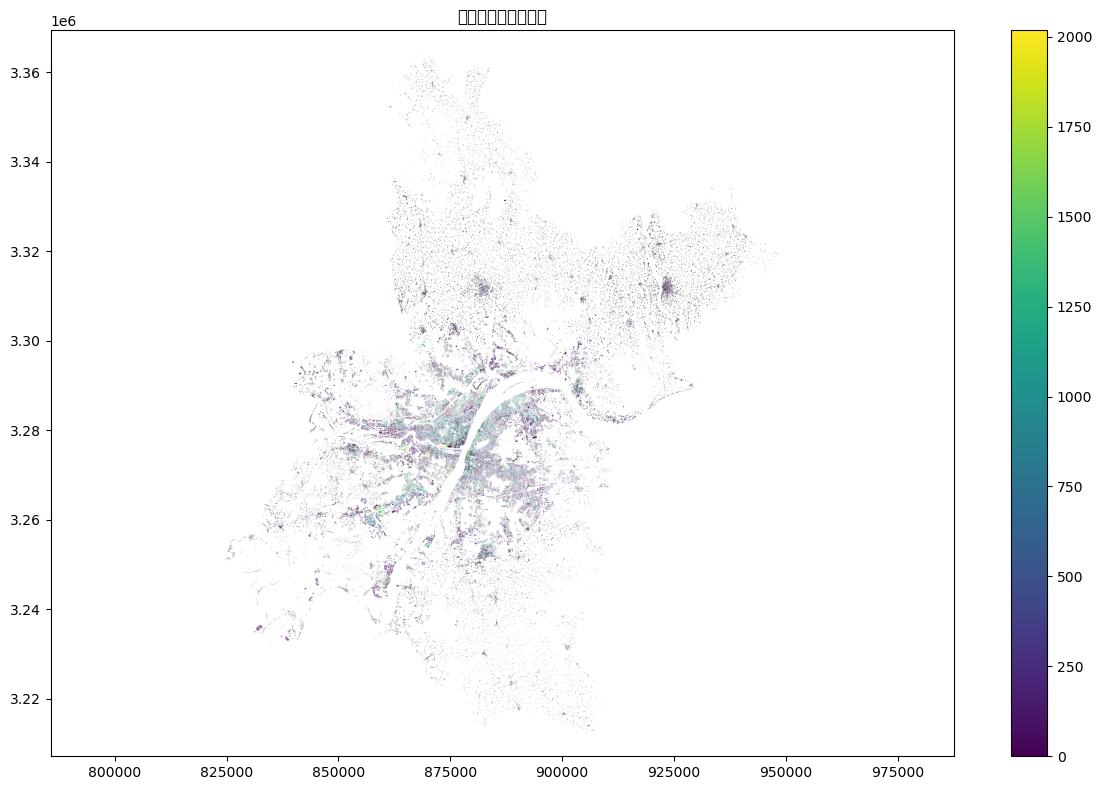

In [6]:
import geopandas as gpd
import rasterio
import pandas as pd
from rasterio.features import geometry_mask
import numpy as np

# 读取建筑物数据
building_path = r"F:\ScientificDatabase\paper03\wuhan_district\Wuhan_Building_GloBFP_with_area.shp"
buildings_gdf = gpd.read_file(building_path)

# 读取能源消耗数据
energy_path = r"F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\wuhan_clipped\wuhan_2018_combined_masked.tif"
with rasterio.open(energy_path) as src:
    energy_data = src.read(1)  # 读取第一波段数据
    energy_transform = src.transform  # 获取栅格的仿射变换
    energy_crs = src.crs  # 获取栅格的坐标参考系统

# 确保建筑物数据和能源数据的坐标系一致
if buildings_gdf.crs != energy_crs:
    print("正在进行坐标系转换...")
    buildings_gdf = buildings_gdf.to_crs(energy_crs)

# 提取建筑物的几何中心点
buildings_gdf['centroid'] = buildings_gdf.geometry.centroid

# 提取中心点对应的能源消耗值
centroids = [(point.x, point.y) for point in buildings_gdf['centroid']]
with rasterio.open(energy_path) as src:
    energy_values = list(src.sample(centroids))

# 将能源值添加到建筑物数据中 - 修复条件判断问题
buildings_gdf['energy_consumption'] = [float(val[0]) if not np.isnan(val[0]) else None for val in energy_values]

# 生成数据表格
data_table = buildings_gdf[['geometry', 'area', 'energy_consumption']]

# 保存为 CSV 文件
output_csv_path = r"F:\ScientificDatabase\paper03\wuhan_district\building_energy_data.csv"
data_table.to_csv(output_csv_path, index=False, encoding='utf-8')
print(f"数据表格已保存到: {output_csv_path}")

# 可视化结果（可选）
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
buildings_gdf.plot(column='energy_consumption', ax=ax, cmap='viridis', legend=True)
plt.title("建筑物能源消耗分布")
plt.axis('equal')
plt.tight_layout()
plt.show()

In [9]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box, Polygon
import math
from scipy.spatial import Voronoi
from shapely.ops import voronoi_diagram
from shapely.ops import unary_union

# 读取江岸区建筑物数据
building_path = r"F:\ScientificDatabase\paper03\wuhan_district\jiangan_buildings.shp"
buildings_gdf = gpd.read_file(building_path)

# 读取江岸区边界数据
boundary_path = r"F:\ScientificDatabase\paper03\wuhan_district\jiang_an_district.shp"
boundary_gdf = gpd.read_file(boundary_path)

# 获取江岸区总面积（平方米）
district_area = boundary_gdf.geometry.area.sum()
print(f"江岸区总面积: {district_area:.2f} 平方米")

江岸区总面积: 0.01 平方米


C:\Users\asus\AppData\Local\Temp\ipykernel_43392\874699890.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  district_area = boundary_gdf.geometry.area.sum()


In [10]:
# 1. 计算建筑密度 (Building Density)
total_building_area = buildings_gdf['area'].sum()
building_density = (total_building_area / district_area) * 100
print(f"建筑密度: {building_density:.2f}% (建筑面积 / 区域总面积)")

建筑密度: 0.00% (建筑面积 / 区域总面积)


In [11]:
# 2. 计算楼面比例 (Floor Area Ratio, FAR)
# 如果建筑物数据有高度或楼层信息，可以计算楼面比例
if 'height' in buildings_gdf.columns:
    # 假设平均层高为3米
    floor_height = 3.0
    buildings_gdf['floors'] = (buildings_gdf['height'] / floor_height).round().astype(int)
    buildings_gdf['floor_area'] = buildings_gdf['area'] * buildings_gdf['floors']
    total_floor_area = buildings_gdf['floor_area'].sum()
    far = total_floor_area / district_area
    print(f"楼面比例 (FAR): {far:.2f}")
else:
    print("缺少高度数据，无法计算楼面比例")


缺少高度数据，无法计算楼面比例


In [12]:
# 3. 计算建筑覆盖率 (Building Coverage Ratio, BCR)
bcr = (total_building_area / district_area) * 100
print(f"建筑覆盖率: {bcr:.2f}%")

建筑覆盖率: 0.00%


In [13]:
# 4. 计算平均建筑面积 (Average Building Area)
avg_building_area = buildings_gdf['area'].mean()
print(f"平均建筑面积: {avg_building_area:.2f} 平方米")


平均建筑面积: 0.00 平方米


In [14]:
# 5. 计算建筑物数量密度 (Building Count Density)
building_count = len(buildings_gdf)
building_count_density = building_count / (district_area / 1000000)  # 每平方公里
print(f"建筑物总数: {building_count}")
print(f"建筑物数量密度: {building_count_density:.2f} 栋/平方公里")

建筑物总数: 34023
建筑物数量密度: 4662251255778.22 栋/平方公里


In [15]:
# 6. 计算平均建筑物间距 (Average Building Distance)
# 使用Voronoi图来估计建筑物间的距离
try:
    # 提取建筑物中心点
    buildings_gdf['centroid'] = buildings_gdf.geometry.centroid
    points = np.array([(point.x, point.y) for point in buildings_gdf['centroid']])
    
    # 创建边界多边形以限制Voronoi图
    boundary = boundary_gdf.geometry.iloc[0]
    
    # 计算Voronoi图
    vor = Voronoi(points)
    
    # 计算平均最近邻距离
    distances = []
    for i in range(len(points)):
        dist_to_others = np.sqrt(np.sum((points[i] - points) ** 2, axis=1))
        dist_to_others = dist_to_others[dist_to_others > 0]  # 排除自身
        if len(dist_to_others) > 0:
            distances.append(np.min(dist_to_others))
    
    avg_building_distance = np.mean(distances)
    print(f"平均最近建筑物间距: {avg_building_distance:.2f} 米")
except Exception as e:
    print(f"计算平均建筑物间距时出错: {e}")


C:\Users\asus\AppData\Local\Temp\ipykernel_43392\3411845222.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings_gdf['centroid'] = buildings_gdf.geometry.centroid


平均最近建筑物间距: 0.00 米


In [16]:
# 7. 计算建筑高度相关指标（如果有高度数据）
if 'height' in buildings_gdf.columns:
    avg_height = buildings_gdf['height'].mean()
    max_height = buildings_gdf['height'].max()
    min_height = buildings_gdf['height'].min()
    std_height = buildings_gdf['height'].std()
    print(f"平均建筑高度: {avg_height:.2f} 米")
    print(f"最大建筑高度: {max_height:.2f} 米")
    print(f"最小建筑高度: {min_height:.2f} 米")
    print(f"建筑高度标准差: {std_height:.2f} 米")
else:
    print("缺少高度数据，无法计算高度相关指标")


缺少高度数据，无法计算高度相关指标


In [17]:
# 8. 计算街区尺度 (Block Size)
try:
    # 使用建筑物轮廓的凸包来近似街区
    from shapely.ops import cascaded_union
    from scipy.spatial import ConvexHull
    
    # 合并所有建筑物形状
    all_buildings = unary_union(buildings_gdf.geometry)
    
    # 计算街区面积
    avg_block_size = all_buildings.convex_hull.area / building_count
    print(f"平均街区尺度: {avg_block_size:.2f} 平方米")
except Exception as e:
    print(f"计算街区尺度时出错: {e}")


平均街区尺度: 0.00 平方米


c:\Users\asus\.conda\envs\play\Lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\asus\.conda\envs\play\Lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 31569 (\N{CJK UNIFIED IDEOGRAPH-7B51}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\asus\.conda\envs\play\Lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\asus\.conda\envs\play\Lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\asus\.conda\envs\play\Lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Us

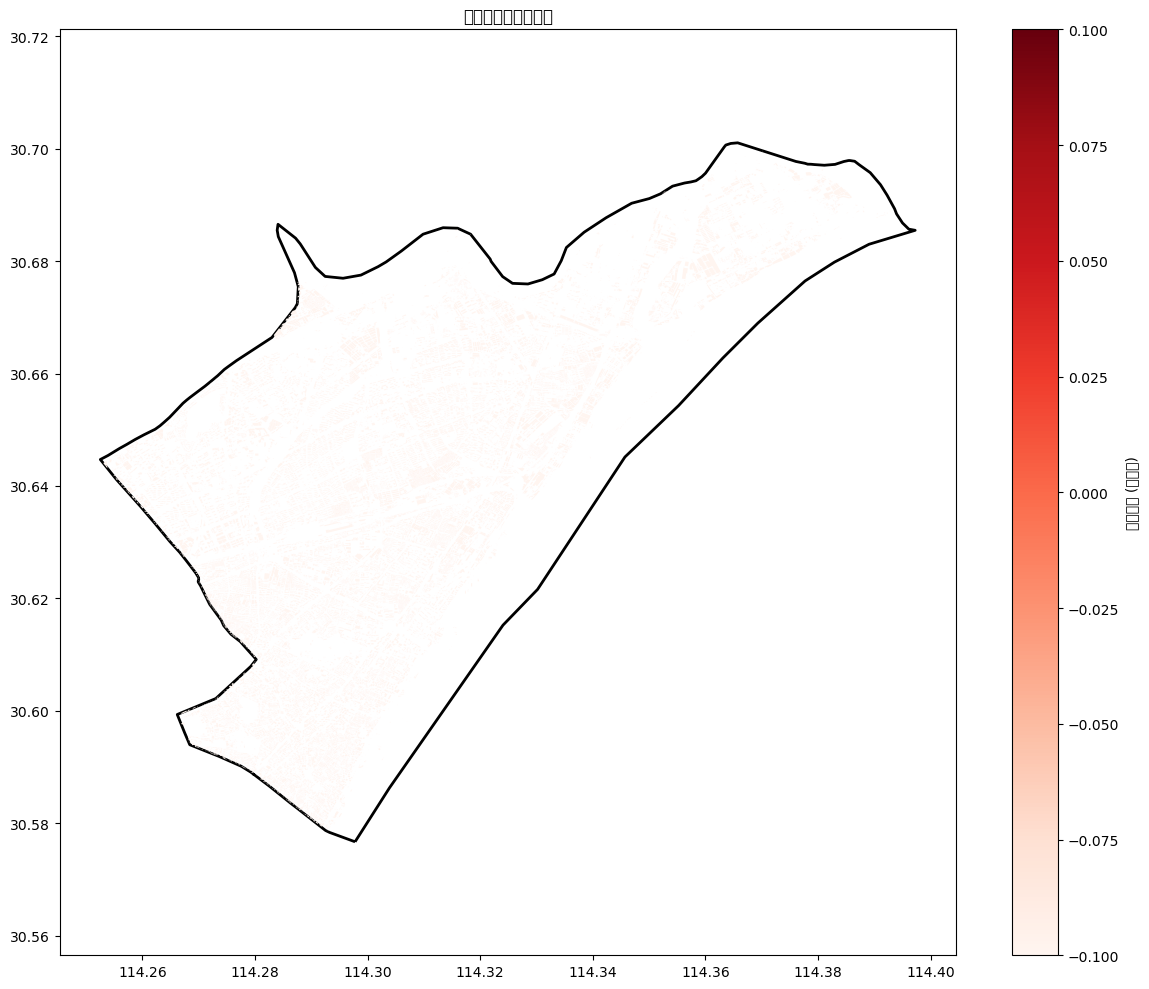

In [18]:

# 9. 可视化建筑密度分布
fig, ax = plt.subplots(figsize=(12, 10))

# 绘制江岸区边界
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2)

# 根据建筑面积绘制建筑物
buildings_gdf.plot(column='area', ax=ax, cmap='Reds', legend=True, 
                  legend_kwds={'label': "建筑面积 (平方米)"})

plt.title("江岸区建筑面积分布")
plt.axis('equal')
plt.tight_layout()
plt.show()


In [19]:

# 10. 保存城市形态数据到CSV文件
import pandas as pd

urban_morphology = {
    '指标': ['区域总面积（平方米）', '建筑密度（%）', '建筑覆盖率（%）', '平均建筑面积（平方米）', 
           '建筑物总数', '建筑物数量密度（栋/平方公里）', '平均最近建筑物间距（米）'],
    '数值': [district_area, building_density, bcr, avg_building_area, 
           building_count, building_count_density, avg_building_distance]
}

if 'height' in buildings_gdf.columns:
    urban_morphology['指标'].extend(['平均建筑高度（米）', '最大建筑高度（米）', 
                                 '最小建筑高度（米）', '建筑高度标准差（米）'])
    urban_morphology['数值'].extend([avg_height, max_height, min_height, std_height])

try:
    urban_morphology['指标'].append('平均街区尺度（平方米）')
    urban_morphology['数值'].append(avg_block_size)
except:
    pass

# 创建数据框并保存
morphology_df = pd.DataFrame(urban_morphology)
morphology_output = r"F:\ScientificDatabase\paper03\wuhan_district\jiangan_urban_morphology.csv"
morphology_df.to_csv(morphology_output, index=False, encoding='utf-8')
print(f"城市形态数据已保存到: {morphology_output}")

城市形态数据已保存到: F:\ScientificDatabase\paper03\wuhan_district\jiangan_urban_morphology.csv


# UMEC

# 计算城市能源韧性的形态因素

我会为您重写代码，以计算影响城市能源韧性的关键形态因素，并按步骤进行。这些指标将帮助我们分析城市形态与能源韧性之间的关系。

## 第一步：读取数据和基础准备



In [20]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box, Polygon
import math
from scipy.spatial import Voronoi
from shapely.ops import unary_union
import rasterio

# 读取江岸区边界数据
boundary_path = r"F:\ScientificDatabase\paper03\wuhan_district\jiang_an_district.shp"
boundary_gdf = gpd.read_file(boundary_path)

# 读取江岸区建筑物数据
building_path = r"F:\ScientificDatabase\paper03\wuhan_district\jiangan_buildings.shp"
buildings_gdf = gpd.read_file(building_path)

# 读取能源消耗数据
energy_path = r"F:\ScientificDatabase\electricity_downscaling_data\China_1km_Ele_201204_201912\wuhan_clipped\wuhan_2018_combined_masked.tif"
with rasterio.open(energy_path) as src:
    energy_data = src.read(1)
    energy_transform = src.transform
    energy_crs = src.crs

# 获取江岸区总面积（平方米）
district_area = boundary_gdf.geometry.area.sum()
print(f"江岸区总面积: {district_area:.2f} 平方米")

江岸区总面积: 0.01 平方米


C:\Users\asus\AppData\Local\Temp\ipykernel_43392\2317400332.py:27: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  district_area = boundary_gdf.geometry.area.sum()




## 第二步：计算紧凑度指标 (能源效率的关键指标)



In [21]:
# 1. 建筑密度：反映能源基础设施的空间集中度
total_building_area = buildings_gdf['area'].sum()
building_density = (total_building_area / district_area) * 100
print(f"建筑密度: {building_density:.2f}% (建筑面积 / 区域总面积)")

# 2. 建筑覆盖率：反映土地利用效率
bcr = (total_building_area / district_area) * 100
print(f"建筑覆盖率: {bcr:.2f}%")

# 3. 建筑物数量密度：影响能源分配网络的复杂性
building_count = len(buildings_gdf)
building_count_density = building_count / (district_area / 1000000)  # 每平方公里
print(f"建筑物总数: {building_count}")
print(f"建筑物数量密度: {building_count_density:.2f} 栋/平方公里")

建筑密度: 0.00% (建筑面积 / 区域总面积)
建筑覆盖率: 0.00%
建筑物总数: 34023
建筑物数量密度: 4662251255778.22 栋/平方公里




## 第三步：计算空间分布指标 (能源网络韧性相关)



In [22]:
# 4. 建筑物空间分布：影响能源网络的冗余性和抗灾能力
try:
    # 提取建筑物中心点
    buildings_gdf['centroid'] = buildings_gdf.geometry.centroid
    points = np.array([(point.x, point.y) for point in buildings_gdf['centroid']])
    
    # 最近邻分析：评估能源节点的空间分布均匀性
    distances = []
    for i in range(len(points)):
        dist_to_others = np.sqrt(np.sum((points[i] - points) ** 2, axis=1))
        dist_to_others = dist_to_others[dist_to_others > 0]  # 排除自身
        if len(dist_to_others) > 0:
            distances.append(np.min(dist_to_others))
    
    avg_building_distance = np.mean(distances)
    std_building_distance = np.std(distances)
    cv_building_distance = std_building_distance / avg_building_distance  # 变异系数，衡量分布均匀性
    
    print(f"平均最近建筑物间距: {avg_building_distance:.2f} 米")
    print(f"建筑物间距标准差: {std_building_distance:.2f} 米")
    print(f"建筑物间距变异系数: {cv_building_distance:.4f} (越低表示分布越均匀)")
    
    # 5. 计算空间聚类度：评估能源负荷的空间聚集程度
    from sklearn.cluster import DBSCAN
    
    # 将坐标归一化以适应DBSCAN
    X = np.column_stack((points[:,0], points[:,1]))
    X_normalized = (X - X.mean(axis=0)) / X.std(axis=0)
    
    # 使用DBSCAN进行聚类
    db = DBSCAN(eps=0.15, min_samples=5).fit(X_normalized)
    labels = db.labels_
    
    # 统计聚类结果
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"识别出的建筑物聚类数: {n_clusters}")
    print(f"聚类密度 (聚类数/平方公里): {n_clusters/(district_area/1000000):.2f}")
    
except Exception as e:
    print(f"计算空间分布指标时出错: {e}")

C:\Users\asus\AppData\Local\Temp\ipykernel_43392\1031864652.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings_gdf['centroid'] = buildings_gdf.geometry.centroid


平均最近建筑物间距: 0.00 米
建筑物间距标准差: 0.00 米
建筑物间距变异系数: 0.6040 (越低表示分布越均匀)
识别出的建筑物聚类数: 2
聚类密度 (聚类数/平方公里): 274064677.18




## 第四步：计算多样性与均衡度指标 (能源系统稳定性相关)



In [23]:
# 6. 建筑面积多样性：评估能源需求的多样化程度
area_bins = pd.cut(buildings_gdf['area'], bins=5)
area_diversity = area_bins.value_counts()
area_diversity_normalized = area_diversity / area_diversity.sum()

# 计算Shannon多样性指数
shannon_diversity = -np.sum(area_diversity_normalized * np.log(area_diversity_normalized))
print(f"建筑面积多样性指数 (Shannon): {shannon_diversity:.4f}")

# 7. 计算建筑面积的基尼系数：反映能源消费不平等程度
def gini_coefficient(x):
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return 1 - 2 * np.sum(cumx) / (n * np.sum(x)) + 1/n

gini = gini_coefficient(buildings_gdf['area'])
print(f"建筑面积基尼系数: {gini:.4f} (越接近1表示不平等程度越高)")

建筑面积多样性指数 (Shannon): -0.0000
建筑面积基尼系数: nan (越接近1表示不平等程度越高)


c:\Users\asus\.conda\envs\play\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\asus\AppData\Local\Temp\ipykernel_43392\3570648264.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - 2 * np.sum(cumx) / (n * np.sum(x)) + 1/n




## 第五步：计算连通性指标 (能源网络可靠性相关)



In [24]:
# 8. 空间邻近度：评估能源网络的连通潜力
try:
    # 计算每个建筑物在一定距离内的邻居数量
    threshold_distance = 50  # 50米作为邻近阈值
    
    avg_neighbors = []
    for i, point in enumerate(points):
        neighbors = np.sum(np.sqrt(np.sum((points - point) ** 2, axis=1)) < threshold_distance) - 1  # 减去自身
        avg_neighbors.append(neighbors)
    
    mean_neighbors = np.mean(avg_neighbors)
    print(f"平均邻近建筑物数量 (50米内): {mean_neighbors:.2f}")
    
    # 9. 计算区域的分形维度：反映城市形态的复杂性
    # 使用盒计数法估计分形维度
    from sklearn.cluster import KMeans
    
    # 计算不同尺度下的盒子数量
    scales = np.logspace(1, 3, num=10)  # 从10m到1000m的尺度范围
    counts = []
    
    for scale in scales:
        kmeans = KMeans(n_clusters=int(max(district_area/(scale*scale), 1)))
        kmeans.fit(points)
        # 计算非空盒子数量
        cluster_points = pd.DataFrame(points).groupby(kmeans.labels_).count()
        non_empty_boxes = len(cluster_points)
        counts.append(non_empty_boxes)
    
    # 计算分形维度（斜率的负值）
    log_scales = np.log(scales)
    log_counts = np.log(counts)
    polyfit = np.polyfit(log_scales, log_counts, 1)
    fractal_dim = -polyfit[0]
    
    print(f"城市形态分形维度: {fractal_dim:.4f} (越接近2表示填充空间能力越强)")
    
except Exception as e:
    print(f"计算连通性指标时出错: {e}")

平均邻近建筑物数量 (50米内): 34022.00
城市形态分形维度: -0.0000 (越接近2表示填充空间能力越强)




## 第六步：分析与能源消耗的关系



In [25]:
# 10. 将能源消耗与建筑物关联
try:
    if 'energy_consumption' not in buildings_gdf.columns:
        print("正在提取建筑物的能源消耗数据...")
        # 确保坐标系一致
        if buildings_gdf.crs != energy_crs:
            buildings_gdf = buildings_gdf.to_crs(energy_crs)
        
        # 提取建筑物中心点对应的能源消耗值
        buildings_gdf['centroid'] = buildings_gdf.geometry.centroid
        centroids = [(point.x, point.y) for point in buildings_gdf['centroid']]
        
        with rasterio.open(energy_path) as src:
            energy_values = list(src.sample(centroids))
        
        # 将能源值添加到建筑物数据中
        buildings_gdf['energy_consumption'] = [float(val[0]) if not np.isnan(val[0]) else None for val in energy_values]
    
    # 计算能源消耗与形态指标的相关性
    valid_energy = buildings_gdf.dropna(subset=['energy_consumption'])
    
    # 计算每单位面积的能源消耗
    valid_energy['energy_per_area'] = valid_energy['energy_consumption'] / valid_energy['area']
    
    # 描述性统计
    print(f"有效能源数据的建筑物数量: {len(valid_energy)}")
    print(f"总能源消耗: {valid_energy['energy_consumption'].sum():.2f}")
    print(f"平均每栋建筑能源消耗: {valid_energy['energy_consumption'].mean():.2f}")
    print(f"平均每平方米能源消耗: {valid_energy['energy_per_area'].mean():.4f}")
    
    # 计算能源效率密度：单位面积的能源消耗与建筑密度的比值
    energy_efficiency_density = valid_energy['energy_per_area'].mean() / (building_density/100)
    print(f"能源效率密度: {energy_efficiency_density:.4f} (越低表示形态能源效率越高)")
    
except Exception as e:
    print(f"分析能源消耗关系时出错: {e}")

正在提取建筑物的能源消耗数据...
有效能源数据的建筑物数量: 34023
总能源消耗: 19001960.61
平均每栋建筑能源消耗: 558.50
平均每平方米能源消耗: inf
能源效率密度: inf (越低表示形态能源效率越高)




## 第七步：可视化关键指标



c:\Users\asus\.conda\envs\play\Lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\asus\.conda\envs\play\Lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 31569 (\N{CJK UNIFIED IDEOGRAPH-7B51}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\asus\.conda\envs\play\Lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\asus\.conda\envs\play\Lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Users\asus\.conda\envs\play\Lib\site-packages\geopandas\plotting.py:956: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
c:\Us

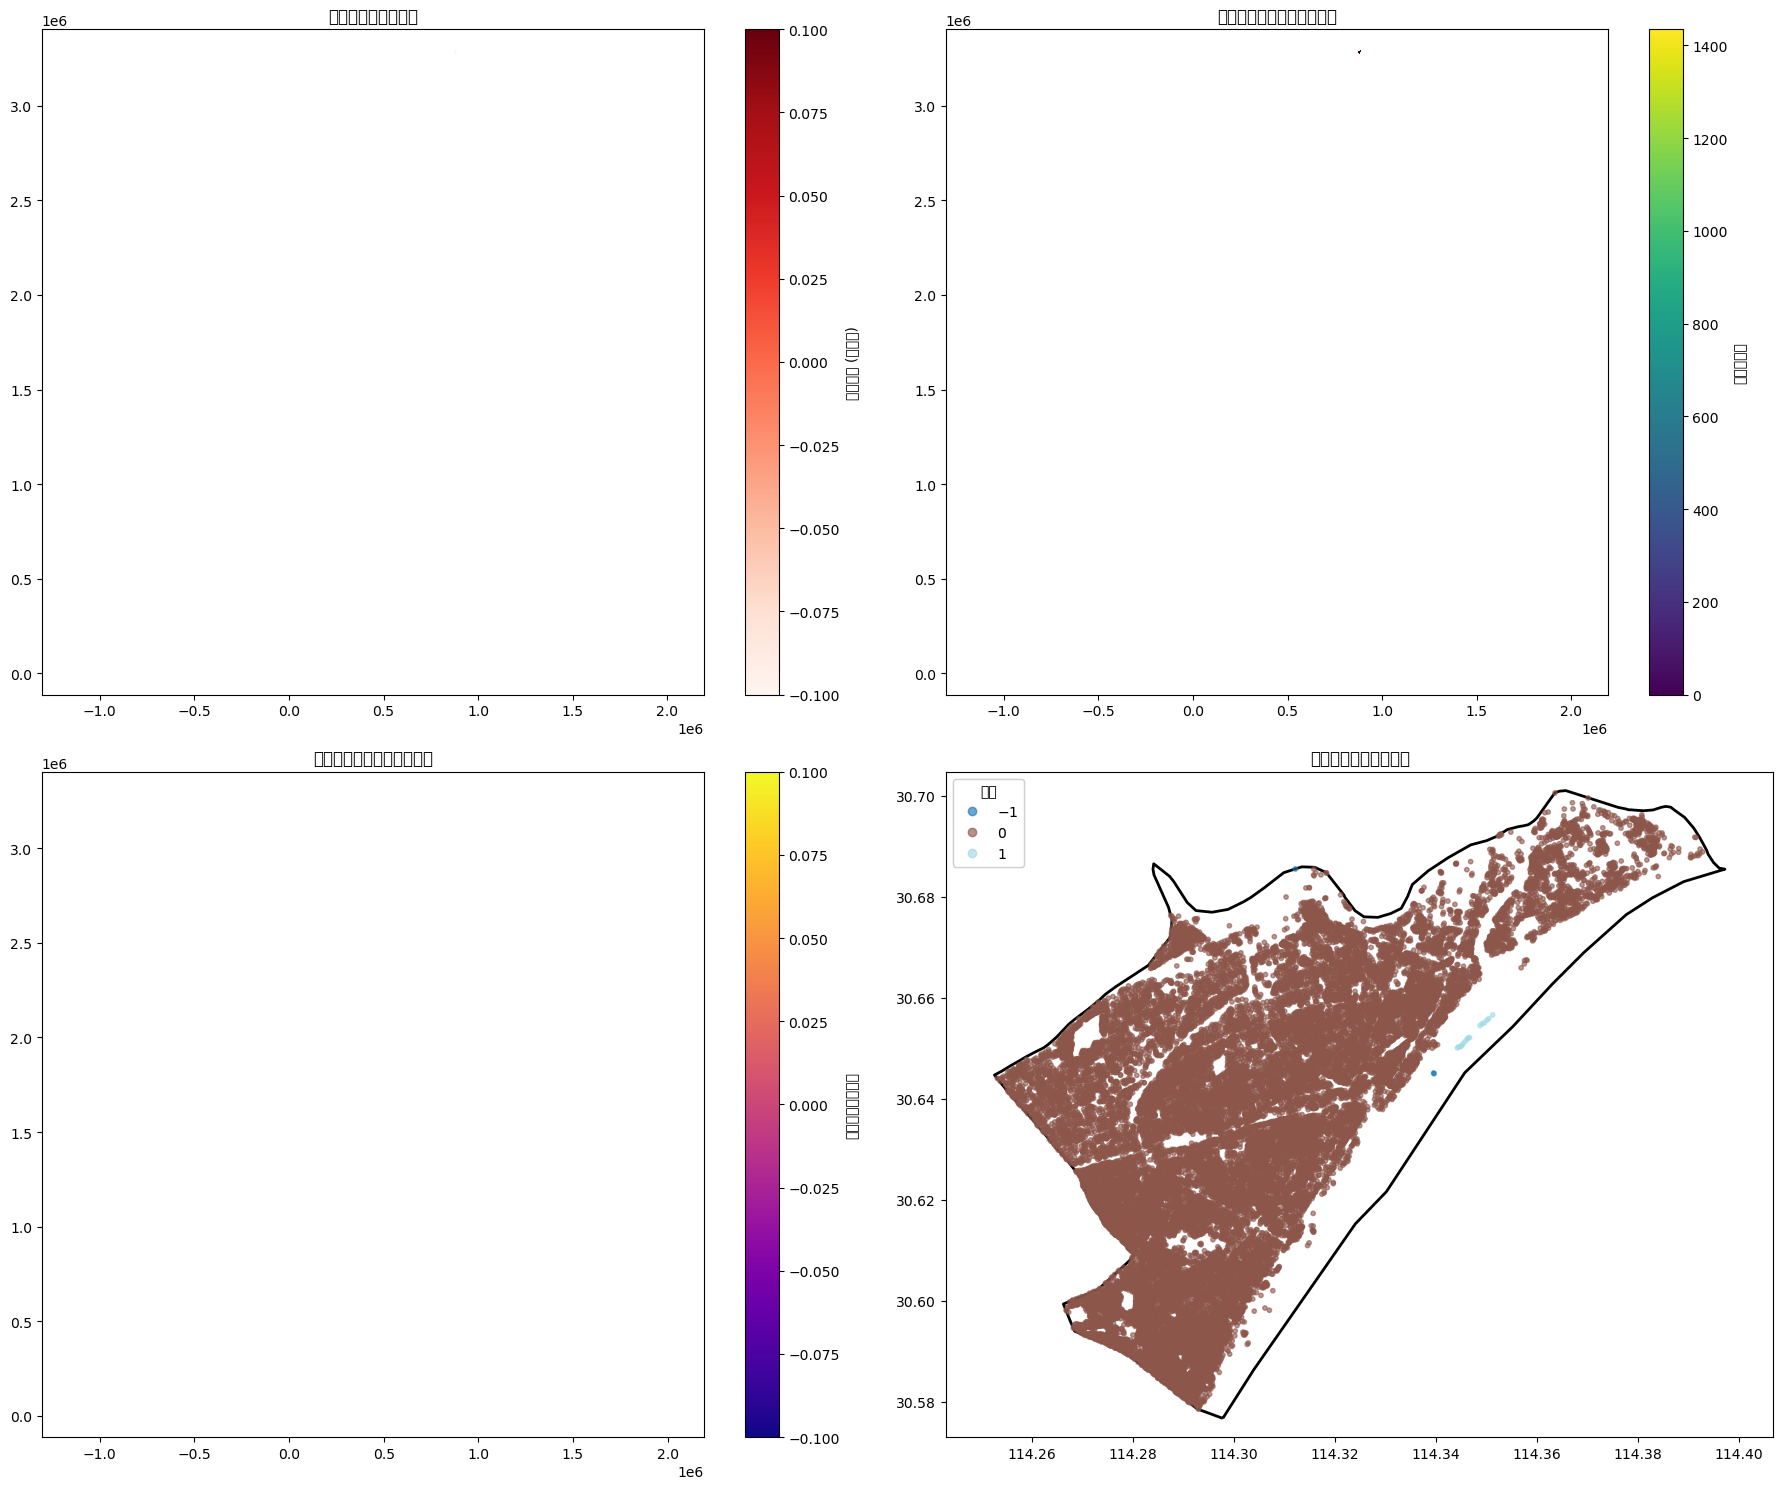

In [26]:
# 11. 可视化建筑物分布与能源消耗
fig, axes = plt.subplots(2, 2, figsize=(18, 15))

# 1. 建筑物空间分布
ax = axes[0, 0]
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2)
buildings_gdf.plot(column='area', ax=ax, cmap='Reds', legend=True, 
                  legend_kwds={'label': "建筑面积 (平方米)"})
ax.set_title("江岸区建筑面积分布")
ax.axis('equal')

# 2. 能源消耗分布
ax = axes[0, 1]
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2)
if 'energy_consumption' in buildings_gdf.columns:
    buildings_gdf.plot(column='energy_consumption', ax=ax, cmap='viridis', legend=True,
                      legend_kwds={'label': "能源消耗量"})
ax.set_title("江岸区建筑物能源消耗分布")
ax.axis('equal')

# 3. 能源效率分布
ax = axes[1, 0]
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2)
if 'energy_per_area' in valid_energy.columns:
    valid_energy.plot(column='energy_per_area', ax=ax, cmap='plasma', legend=True,
                     legend_kwds={'label': "单位面积能源消耗"})
ax.set_title("江岸区建筑物能源效率分布")
ax.axis('equal')

# 4. 建筑物聚类展示
ax = axes[1, 1]
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2)
try:
    scatter = ax.scatter(points[:, 0], points[:, 1], c=labels, cmap='tab20', s=10, alpha=0.6)
    ax.set_title("江岸区建筑物空间聚类")
    legend1 = ax.legend(*scatter.legend_elements(), title="聚类")
    ax.add_artist(legend1)
except:
    buildings_gdf.plot(ax=ax, color='grey', alpha=0.5)
    ax.set_title("江岸区建筑物分布")
ax.axis('equal')

plt.tight_layout()
plt.show()



## 第八步：保存能源韧性形态指标结果



In [27]:
# 12. 将所有计算的能源韧性形态指标保存到CSV
try:
    # 集合所有指标
    resilience_indices = {
        '指标': [
            '区域总面积（平方米）', 
            '建筑密度（%）', 
            '建筑覆盖率（%）', 
            '建筑物总数',
            '建筑物数量密度（栋/平方公里）',
            '平均最近建筑物间距（米）',
            '建筑物间距变异系数',
            '建筑物聚类数',
            '聚类密度（每平方公里）',
            '建筑面积多样性指数',
            '建筑面积基尼系数',
            '平均邻近建筑物数量（50米内）',
            '城市形态分形维度',
            '总能源消耗',
            '平均每栋建筑能源消耗',
            '平均每平方米能源消耗',
            '能源效率密度'
        ],
        '数值': [
            district_area,
            building_density,
            bcr,
            building_count,
            building_count_density,
            avg_building_distance,
            cv_building_distance,
            n_clusters,
            n_clusters/(district_area/1000000),
            shannon_diversity,
            gini,
            mean_neighbors,
            fractal_dim,
            valid_energy['energy_consumption'].sum(),
            valid_energy['energy_consumption'].mean(),
            valid_energy['energy_per_area'].mean(),
            energy_efficiency_density
        ]
    }
    
    # 创建数据框并保存
    resilience_df = pd.DataFrame(resilience_indices)
    resilience_output = r"F:\ScientificDatabase\paper03\wuhan_district\jiangan_energy_resilience_indices.csv"
    resilience_df.to_csv(resilience_output, index=False, encoding='utf-8')
    print(f"城市能源韧性形态指标已保存到: {resilience_output}")
    
except Exception as e:
    print(f"保存结果时出错: {e}")

城市能源韧性形态指标已保存到: F:\ScientificDatabase\paper03\wuhan_district\jiangan_energy_resilience_indices.csv




这套代码计算了一系列与城市能源韧性相关的形态因素，包括：

1. **紧凑度指标**：建筑密度、建筑覆盖率、建筑物数量密度
2. **空间分布指标**：建筑物间距、变异系数、空间聚类度
3. **多样性指标**：建筑面积多样性指数、基尼系数
4. **连通性指标**：空间邻近度、分形维度
5. **能源效率指标**：单位面积能源消耗、能源效率密度

这些指标可以帮助评估城市形态对能源系统韧性的影响，如效率、冗余性、分散性以及可恢复性等方面。